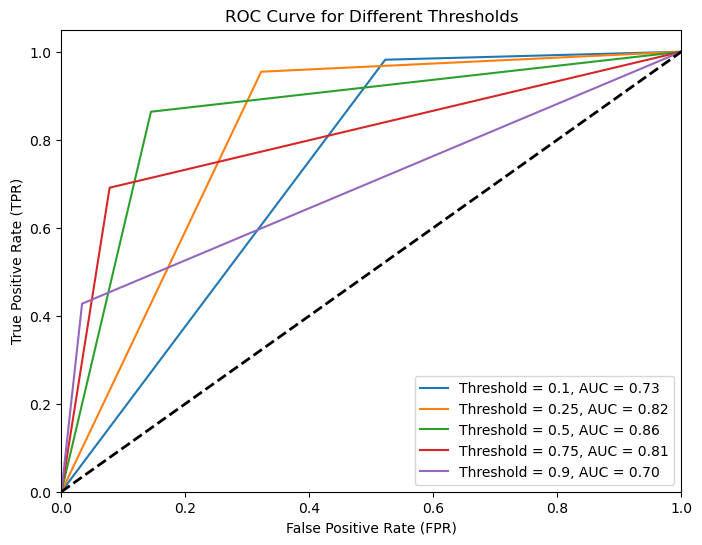

Best Threshold: 0.5
AUC for Best Threshold: 0.86


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Generate synthetic data with 2 classes
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Create a Logistic Regression classifier
clf = LogisticRegression()

# Fit the classifier to the training data
clf.fit(X_train, y_train)

# Predict probabilities for the test data
y_probs = clf.predict_proba(X_test)[:, 1]

# Define different threshold values
thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]

# Initialize lists to store ROC curve data
fpr_list = []
tpr_list = []
roc_auc_list = []

# Calculate ROC curve and AUC for each threshold
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    fpr_list.append(fpr)
    tpr_list.append(tpr)
    roc_auc_list.append(roc_auc)

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i, threshold in enumerate(thresholds):
    plt.plot(fpr_list[i], tpr_list[i], label=f'Threshold = {threshold}, AUC = {roc_auc_list[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)  # Random guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Different Thresholds')
plt.legend(loc="lower right")
plt.show()

# Select the threshold with the highest AUC
best_threshold_idx = np.argmax(roc_auc_list)
best_threshold = thresholds[best_threshold_idx]
best_auc = roc_auc_list[best_threshold_idx]

print(f"Best Threshold: {best_threshold}")
print(f"AUC for Best Threshold: {best_auc:.2f}")
